## Imports

In [16]:
import numpy as np
import astromet
import gaiascanlaw
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.time import Time

import sys
sys.path.append('../errors')
from phot_error import phot_err_CCD

from cmap import Colormap
cm = Colormap('tol:muted')

## Plot settings

In [17]:
import scienceplots
import matplotlib as mpl

plt.style.use('science')
plt.rc('text', usetex=plt.rcParamsDefault['text.usetex'])
mpl.rcParams['font.size'] = 16
mpl.rcParams['figure.figsize'] = (8,6)
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['xtick.major.size'] = 7
mpl.rcParams['ytick.major.size'] = 7

mpl.rcParams['xtick.minor.width'] = 0.5
mpl.rcParams['ytick.minor.width'] = 0.5
mpl.rcParams['xtick.minor.size'] = 5
mpl.rcParams['ytick.minor.size'] = 5

## Load data

For each event we provide three datafiles:
- the mock _Gaia_ DR4 data,
- the true parameters used to create the mock event,
- and a 5-parameter fit _Gaia_ would return given the mock data.

In [18]:
source_path = 'NS151584S2080175978553802752'

data_filename = f'../data/{source_path}.npy'
params_filename = f'../data/{source_path}_true_params.npy'
fit_filename = f'../data/{source_path}_5p_fit_DR4.npy'

mockdata = np.load(data_filename, allow_pickle='TRUE').item()
params = np.load(params_filename, allow_pickle='TRUE').item()
fit_results = np.load(fit_filename, allow_pickle='TRUE').item()

## Visualize time-series data

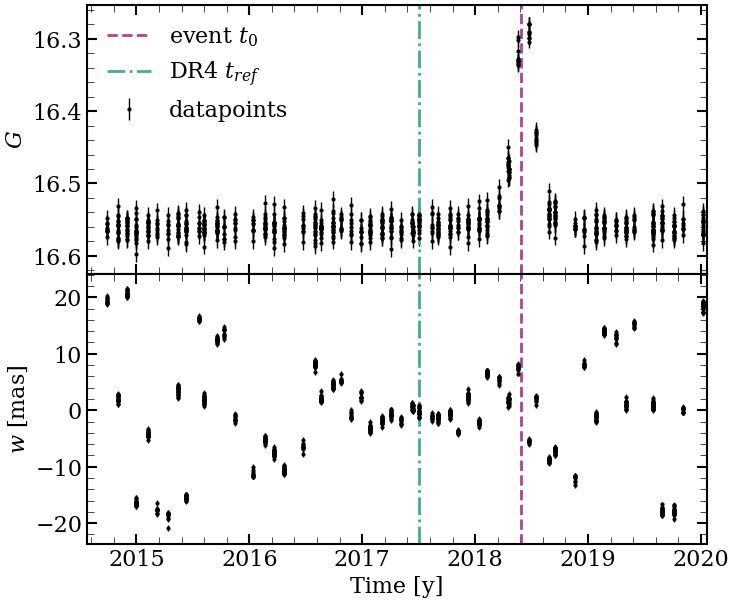

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(8,7), sharex=True)
plt.subplots_adjust(hspace=0)

ax_phot = axes[0]
ax_phot.errorbar(mockdata['time'], mockdata['mags'], yerr=mockdata['emags'], fmt='o', markersize=2, c='k', label='datapoints')
ax_phot.invert_yaxis()
ax_phot.set_ylabel(r'$G$')

ax_ast = axes[1]
ax_ast.errorbar(mockdata['time'], mockdata['w'], yerr=mockdata['wError'], fmt='o', markersize=2, c='k')
ax_ast.set_ylabel(r'$w$ [mas]')
ax_ast.set_xlabel(r'Time [y]')
ax_ast.set_xlim(gaiascanlaw.tstart, gaiascanlaw.tdr4)

for ax in axes:
    ax.axvline(x=params['t0'], c=cm(8), ls='--', lw=2, label=r'event $t_0$')
    ax.axvline(x=2017.5, c=cm(2), ls='-.', lw=2, label=r'DR4 $t_{ref}$')

axes[0].legend(loc='upper left')

While the photometric effect is obvious, the astrometric 1D data is very difficult to interpret without assuming a model!

## View 5-parameter fit results

In [5]:
fit_results

{'vis_periods': np.int64(56),
 'n_obs': 828,
 'params_solved': 5,
 'drac': np.float64(-0.08829642777216878),
 'drac_error': np.float64(0.02623821062115395),
 'ddec': np.float64(0.05976601095329297),
 'ddec_error': np.float64(0.02813887843243704),
 'drac_ddec_corr': np.float64(-0.01684335527583962),
 'parallax': np.float64(0.49771675057251213),
 'parallax_error': np.float64(0.029919532625187414),
 'drac_parallax_corr': np.float64(0.11270021506080405),
 'ddec_parallax_corr': np.float64(-0.03915711562621516),
 'pmrac': np.float64(-3.406014481437017),
 'pmrac_error': np.float64(0.016643902563898427),
 'drac_pmrac_corr': np.float64(0.10979443352273997),
 'ddec_pmrac_corr': np.float64(-0.032917690303320375),
 'parallax_pmrac_corr': np.float64(0.04083971928139609),
 'pmdec': np.float64(-8.120321179778253),
 'pmdec_error': np.float64(0.018645369209199434),
 'drac_pmdec_corr': np.float64(-0.02986822835458345),
 'ddec_pmdec_corr': np.float64(0.09434391482628424),
 'parallax_pmdec_corr': np.float

We can format these results to match the `gaia_source` catalogue columns:

In [6]:
astromet.gaia_results(fit_results)

{'astrometric_matched_transits': 92,
 'visibility_periods_used': np.int64(56),
 'astrometric_n_obs_al': 828,
 'astrometric_params_solved': 31,
 'ra': np.float64(296.2696893978447),
 'ra_error': np.float64(0.02623821062115395),
 'dec': np.float64(45.54603706407267),
 'dec_error': np.float64(0.02813887843243704),
 'ra_dec_corr': np.float64(-0.01684335527583962),
 'parallax': np.float64(0.49771675057251213),
 'parallax_error': np.float64(0.029919532625187414),
 'ra_parallax_corr': np.float64(0.11270021506080405),
 'dec_parallax_corr': np.float64(-0.03915711562621516),
 'pmra': np.float64(-3.406014481437017),
 'pmra_error': np.float64(0.016643902563898427),
 'ra_pmra_corr': np.float64(0.10979443352273997),
 'dec_pmra_corr': np.float64(-0.032917690303320375),
 'parallax_pmra_corr': np.float64(0.04083971928139609),
 'pmdec': np.float64(-8.120321179778253),
 'pmdec_error': np.float64(0.018645369209199434),
 'ra_pmdec_corr': np.float64(-0.02986822835458345),
 'dec_pmdec_corr': np.float64(0.094

## Visualize the 5-parameter fit and residuals

(-21.930623825977516, 25.42323143426522)

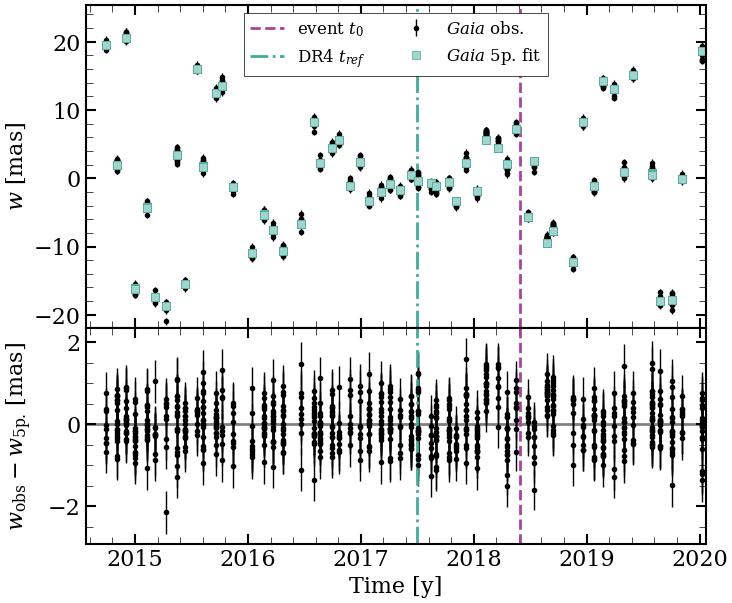

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(8,7), sharex=True, height_ratios = (3, 2))
plt.subplots_adjust(hspace=0)

ax_w = axes[0]

# create a 5-parameter track with input from fit results
p5p = astromet.params()
p5p.epoch, p5p.ra, p5p.dec = mockdata['refEpoch'], fit_results['ra_ref'], fit_results['dec_ref']

for key in ['drac', 'ddec', 'parallax', 'pmrac', 'pmdec']:
    setattr(p5p, key, fit_results[key])

# astromet creates 9 duplicates of each timestamp to match 9 CCDs
# we already have this format in mockdata, so we're taking just one point per transit
ts_transit = mockdata['time'].reshape(int(mockdata['time'].shape[0]/9), 9).T[0]
sc_a_transit = mockdata['sc_a'].reshape(int(mockdata['sc_a'].shape[0]/9), 9).T[0]

# getting positions at ts_transit
racs, decs = astromet.track(ts_transit, p5p)
_, w_5p, _, _, _ = astromet.mock_obs(ts_transit, sc_a_transit, racs, decs, err=0)

# plot observations and model
ax_w.errorbar(mockdata['time'], mockdata['w'], yerr=mockdata['wError'], fmt='o', ms=3, c='k', label = '$Gaia$ obs.')
ax_w.errorbar(mockdata['time'], w_5p, fmt='s', ms=6, mec=cm(2), mew=0.5, mfc='#a2d4cc', label = '$Gaia$ 5p. fit')
ax_w.set_ylabel(r'$w$ [mas]')

# plot residuals
rax = axes[1]
rax.axhline(y=0, lw=2, c='k', alpha=0.5)
rax.errorbar(mockdata['time'], mockdata['w'] - w_5p, yerr=mockdata['wError'], fmt='o', ms=3, c='k')
rax.set_ylabel(r'$w_\text{obs} - w_\text{5p.}$ [mas]', labelpad=10)
rax.set_xlabel(r'Time [y]')

# figure setup
for ax in axes:
    ax.axvline(x=params['t0'], c=cm(8), ls='--', lw=2, label=r'event $t_0$')
    ax.axvline(x=2017.5, c=cm(2), ls='-.', lw=2, label=r'DR4 $t_{ref}$')
    
leg = ax_w.legend(fontsize=12, loc='upper center', ncols=2, frameon=True, framealpha=1, fancybox=False)
leg.get_frame().set_edgecolor('k')
leg.get_frame().set_linewidth(0.5)

ax_w.set_xlim(gaiascanlaw.tstart, gaiascanlaw.tdr4)
ax_w.set_ylim(np.min(mockdata['w']) - 1, np.max(mockdata['w']) + 4) 

## Get your own 5-parameter fit

If you only have some mock data and would like to generate a 5-parameter fit, it's very simple with `astromet`:

In [8]:
results = astromet.fit(mockdata['time'], mockdata['w'], mockdata['sc_a'], mockdata['wError'], mockdata['ra'], mockdata['dec'])
results

{'vis_periods': np.int64(56),
 'n_obs': 828,
 'params_solved': 5,
 'drac': np.float64(5.020725294383334),
 'drac_error': np.float64(0.03417446149379498),
 'ddec': np.float64(12.24024778062065),
 'ddec_error': np.float64(0.03775596828955318),
 'drac_ddec_corr': np.float64(0.00817660613533483),
 'parallax': np.float64(0.4977167505725133),
 'parallax_error': np.float64(0.029919532625187414),
 'drac_parallax_corr': np.float64(0.0566930225800847),
 'ddec_parallax_corr': np.float64(-0.046143156528142736),
 'pmrac': np.float64(-3.4060144814370052),
 'pmrac_error': np.float64(0.016643902563898402),
 'drac_pmrac_corr': np.float64(-0.6462441076959647),
 'ddec_pmrac_corr': np.float64(-0.0011326230031969266),
 'parallax_pmrac_corr': np.float64(0.04083971928139599),
 'pmdec': np.float64(-8.120321179778255),
 'pmdec_error': np.float64(0.018645369209199448),
 'drac_pmdec_corr': np.float64(0.00014560634134484383),
 'ddec_pmdec_corr': np.float64(-0.6704455748434912),
 'parallax_pmdec_corr': np.float64(

## Create your own mock data

If you want to see how an event with some microlensing parameters would look like in _Gaia_ data, you can easily use built-in `astromet` routines for that:

In [9]:
event_ra, event_dec = 30, 30 # event coordinates
u0, t0, tE, piEN, piEE, G0 = 0.7, 2017.8, 0.4, 0.02, 0.06, 15 # photometric microlensing parameters; times are defined in years
f_bl = 1 # fraction of light coming from the source, = 1 for dark lenses
source_pmra, source_pmdec, source_distance = -5, -2, 8 # situate the light source in the Galaxy; distance is defined in kpc
theta_E = 5 # angular on-sky scale of the event in mas

We create a lensing event with these parameters:

In [10]:
params = astromet.params()
params.epoch = 2017.5 # reference for DR4
params = astromet.define_lens(params, event_ra, event_dec, u0, Time(t0, format='decimalyear').jd - 2450000, tE*u.year.to(u.day), piEN, piEE, G0, 1., source_pmra, source_pmdec, source_distance, theta_E)

We get observation times and scanning angles following the _Gaia_ scanning law for the extent of DR4 data:

In [11]:
tstart=gaiascanlaw.tstart
tend=gaiascanlaw.tdr4
ts, phis = gaiascanlaw.scanlaw(event_ra, event_dec, tstart=tstart, tend=tend)

We use `astromet.track` to get the positions and photometric time series at `ts`:

In [12]:
racs, decs, mag_diffs = astromet.track(ts, params)
mags = G0 + mag_diffs

We get astrometric and photometric precision for each epoch:

In [13]:
ast_err = np.repeat(astromet.sigma_ast(mags), 9)
phot_err = np.repeat(phot_err_CCD(mags), 9)

Using the projection directions `phi` and these precision levels, we can convert the `astromet.track` results into _Gaia_ mock data:

In [14]:
t_obs, w_obs, phi_obs, rac_obs, dec_obs = astromet.mock_obs(ts, phis, racs, decs, err=ast_err)
mag_obs = np.repeat(mags, 9) + phot_err*np.random.randn(phot_err.size)

And done! We can now create the exact same plot as at the start of the tutorial, but for our newly simulated event:

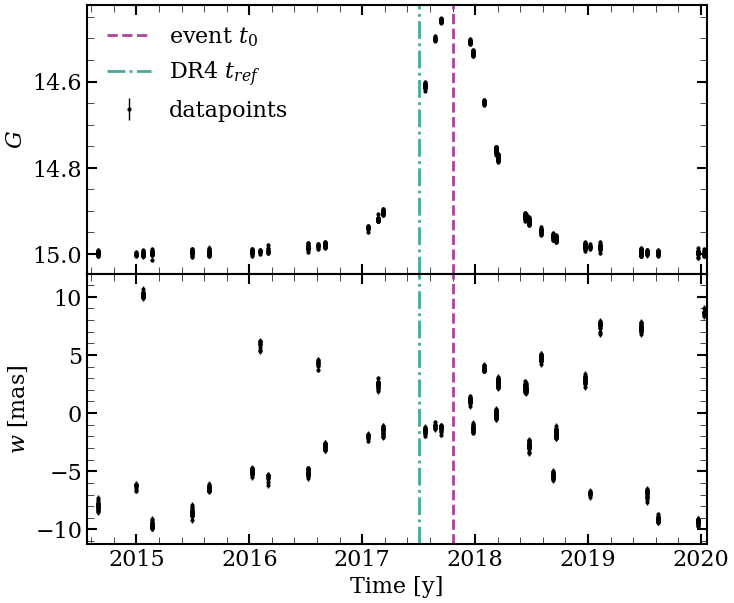

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(8,7), sharex=True)
plt.subplots_adjust(hspace=0)

ax_phot = axes[0]
ax_phot.errorbar(t_obs, mag_obs, yerr=phot_err, fmt='o', markersize=2, c='k', label='datapoints')
ax_phot.invert_yaxis()
ax_phot.set_ylabel(r'$G$')

ax_ast = axes[1]
ax_ast.errorbar(t_obs, w_obs, yerr=ast_err, fmt='o', markersize=2, c='k')
ax_ast.set_ylabel(r'$w$ [mas]')
ax_ast.set_xlabel(r'Time [y]')
ax_ast.set_xlim(tstart, tend)

for ax in axes:
    ax.axvline(x=t0, c=cm(8), ls='--', lw=2, label=r'event $t_0$')
    ax.axvline(x=2017.5, c=cm(2), ls='-.', lw=2, label=r'DR4 $t_{ref}$')

axes[0].legend(loc='upper left')